# Analysis: 20250611

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data, platemap = pr.load_platereader_data("./data/20250611-cytation3-pure-timecourse-gfp-ppk-mg-sweep-biotek-cdk.txt", "20250611-Mg-sweep-platemap.csv")

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

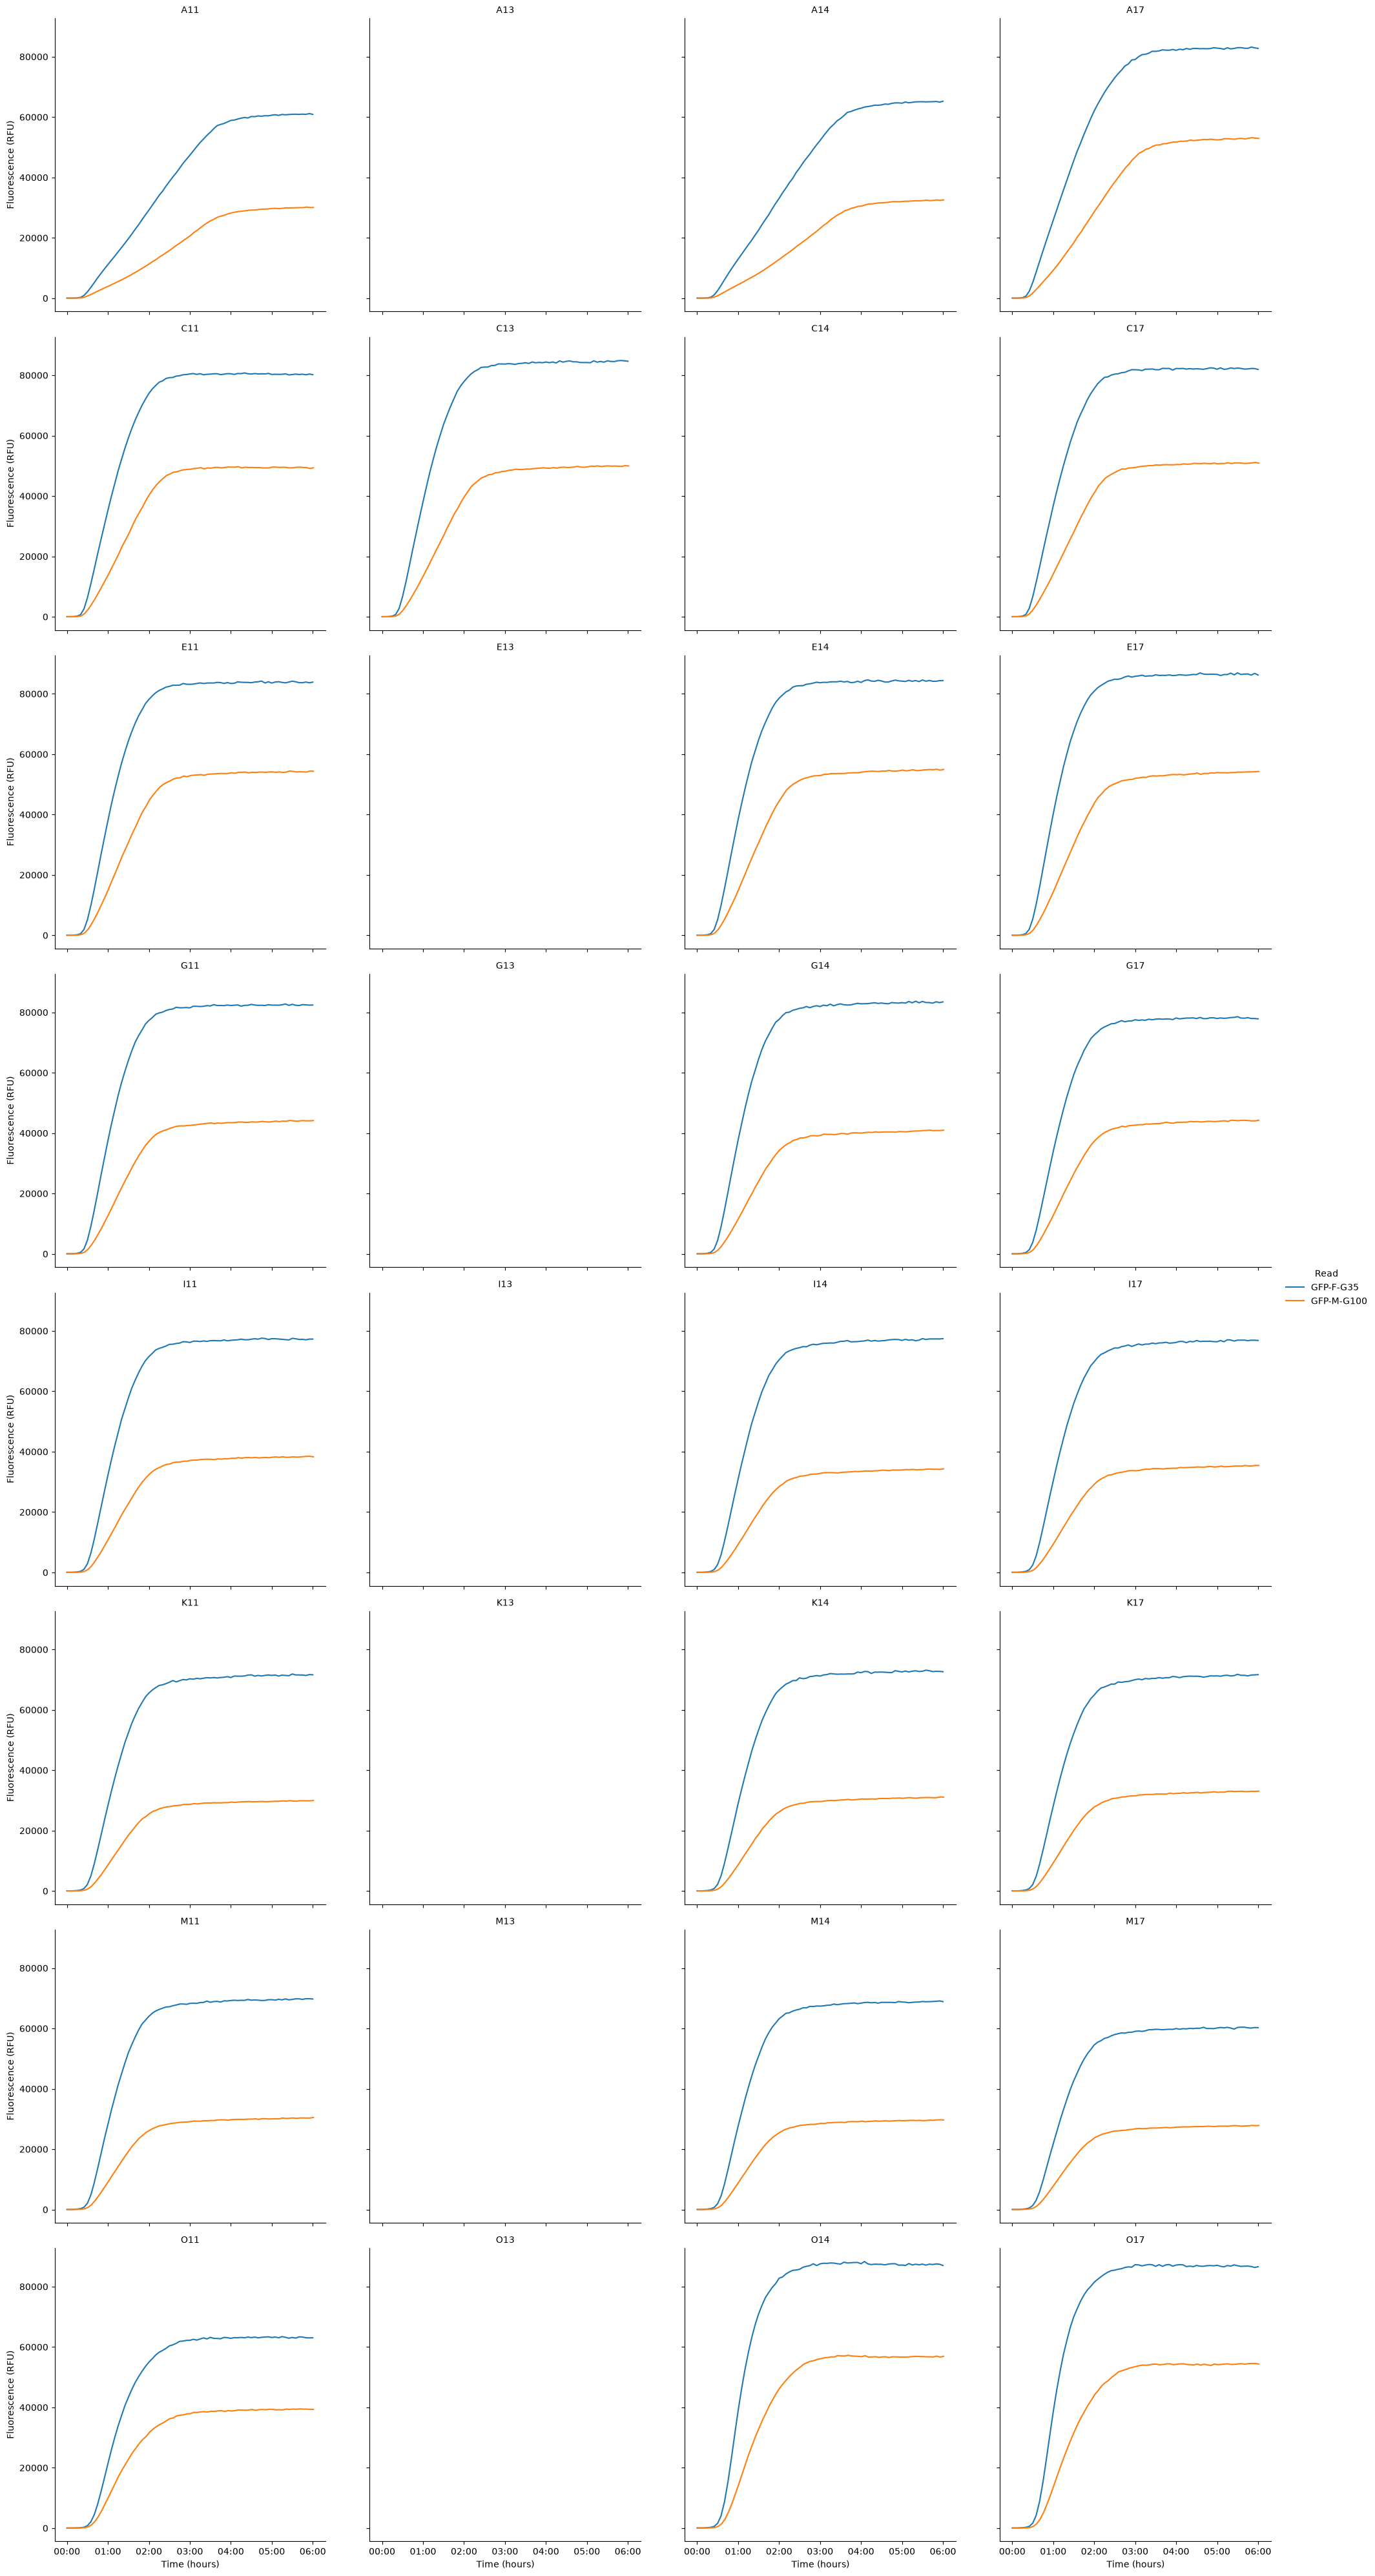

In [4]:
pr.plot_plate(data)

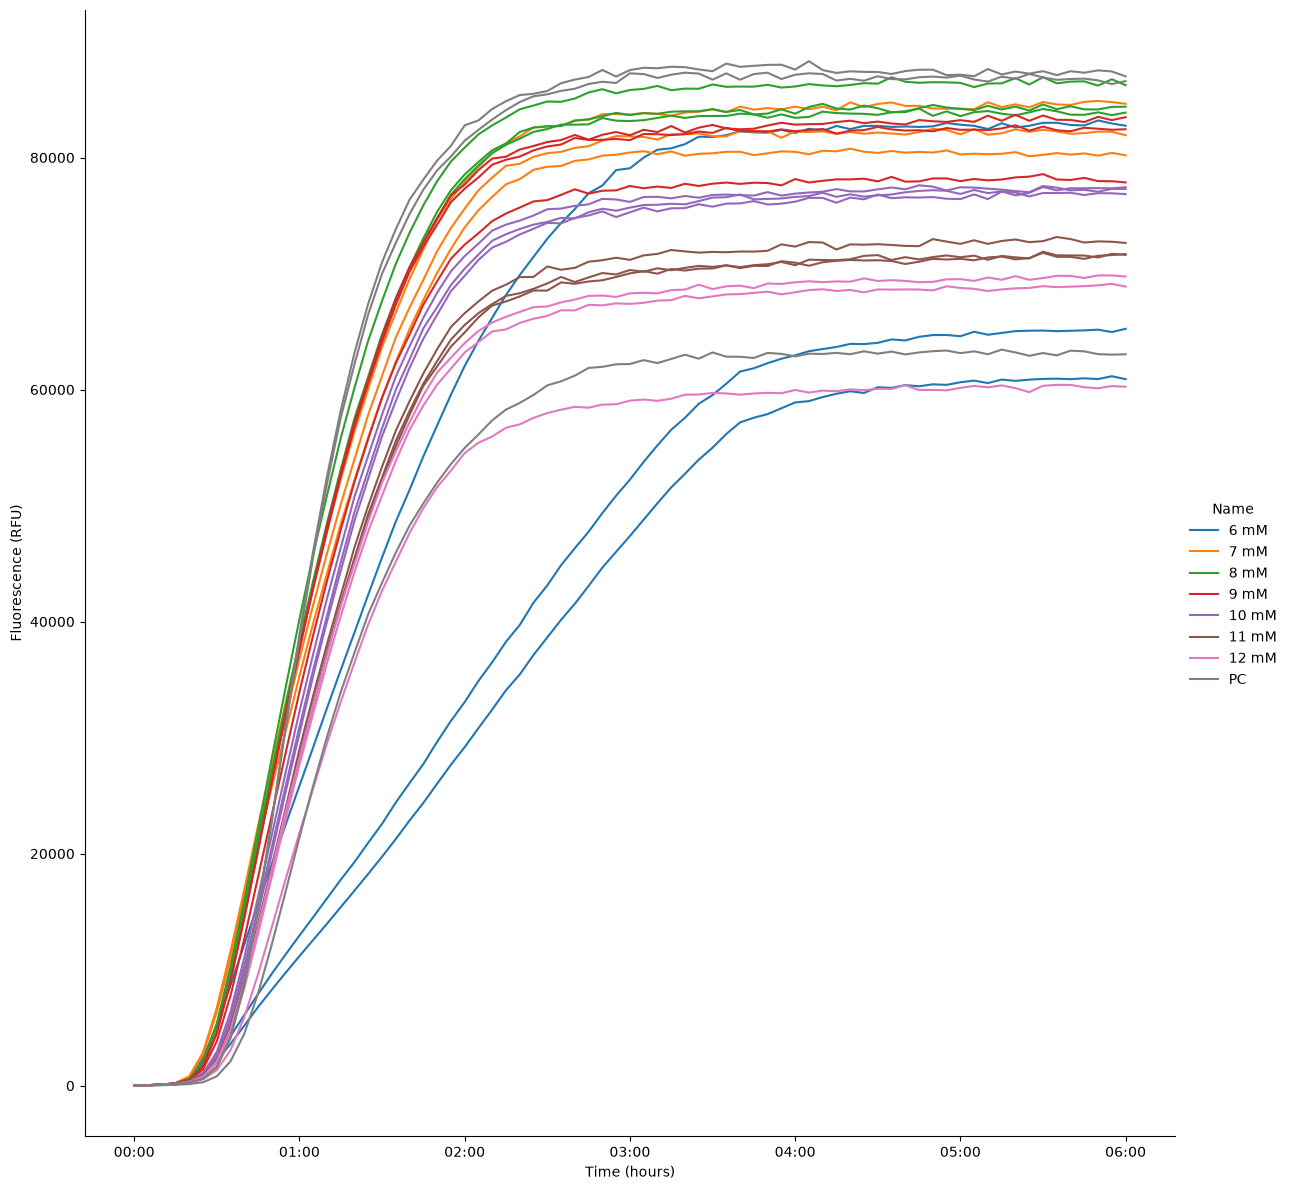

In [5]:
pr.plot_curves(data[data["Read"]=="GFP-F-G35"], units="Well", estimator=None, height=12)

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

<Axes: xlabel='Name', ylabel='Data_steadystate'>

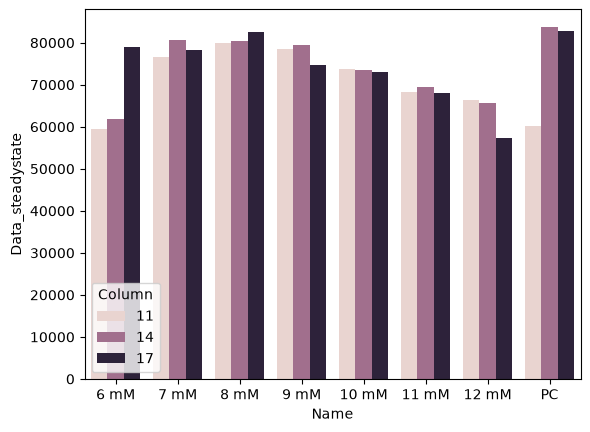

In [6]:
ss = pr.find_steady_state(data[data["Read"]=="GFP-F-G35"], group_by=["Well", "Read"]).reset_index()
ss.columns = [c[0] if c[1] == "" else "_".join(c).strip() for c in ss.columns]
steadystate = data.merge(ss[["Well", "Data_steadystate"]], on="Well", how="left")
steadystate.loc[steadystate["Column"]==13, "Column"] = 14
sns.barplot(data=steadystate, x="Name", y="Data_steadystate", hue="Column")

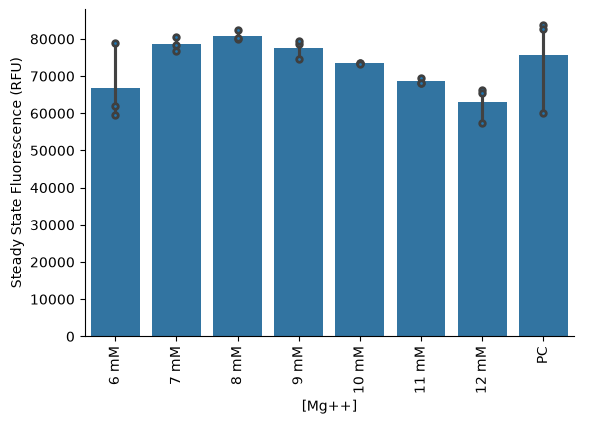

In [7]:
#| label: fig:endpoint-exp2

s= pr.plot_steadystate(data[data["Read"]=="GFP-F-G35"])
plt.xlabel("[Mg++]")
s.savefig("plot3")

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x315df0f50>,
                                  Velocity                    \
                                      Time     Data      Max   
 Name  Read                                                    
 10 mM GFP-F-G35 0 days 01:05:49.421554667 38646.02 63189.62   
 11 mM GFP-F-G35 0 days 01:06:14.707816838 36099.77 58966.93   
 12 mM GFP-F-G35 0 days 01:06:46.304851814 33191.64 54896.20   
 6 mM  GFP-F-G35 0 days 01:41:38.593562542 35161.24 28962.93   
 7 mM  GFP-F-G35 0 days 01:03:17.921594644 41326.12 63567.49   
 8 mM  GFP-F-G35 0 days 01:02:09.307229164 42589.11 71072.49   
 9 mM  GFP-F-G35 0 days 01:02:48.602873044 40804.03 68778.14   
 PC    GFP-F-G35 0 days 01:05:50.688008639 39780.81 74711.19   
 
                                       Lag                      Steady State  \
                                      Time    Data                      Time   
 Name  Read                                                                    
 10 mM G

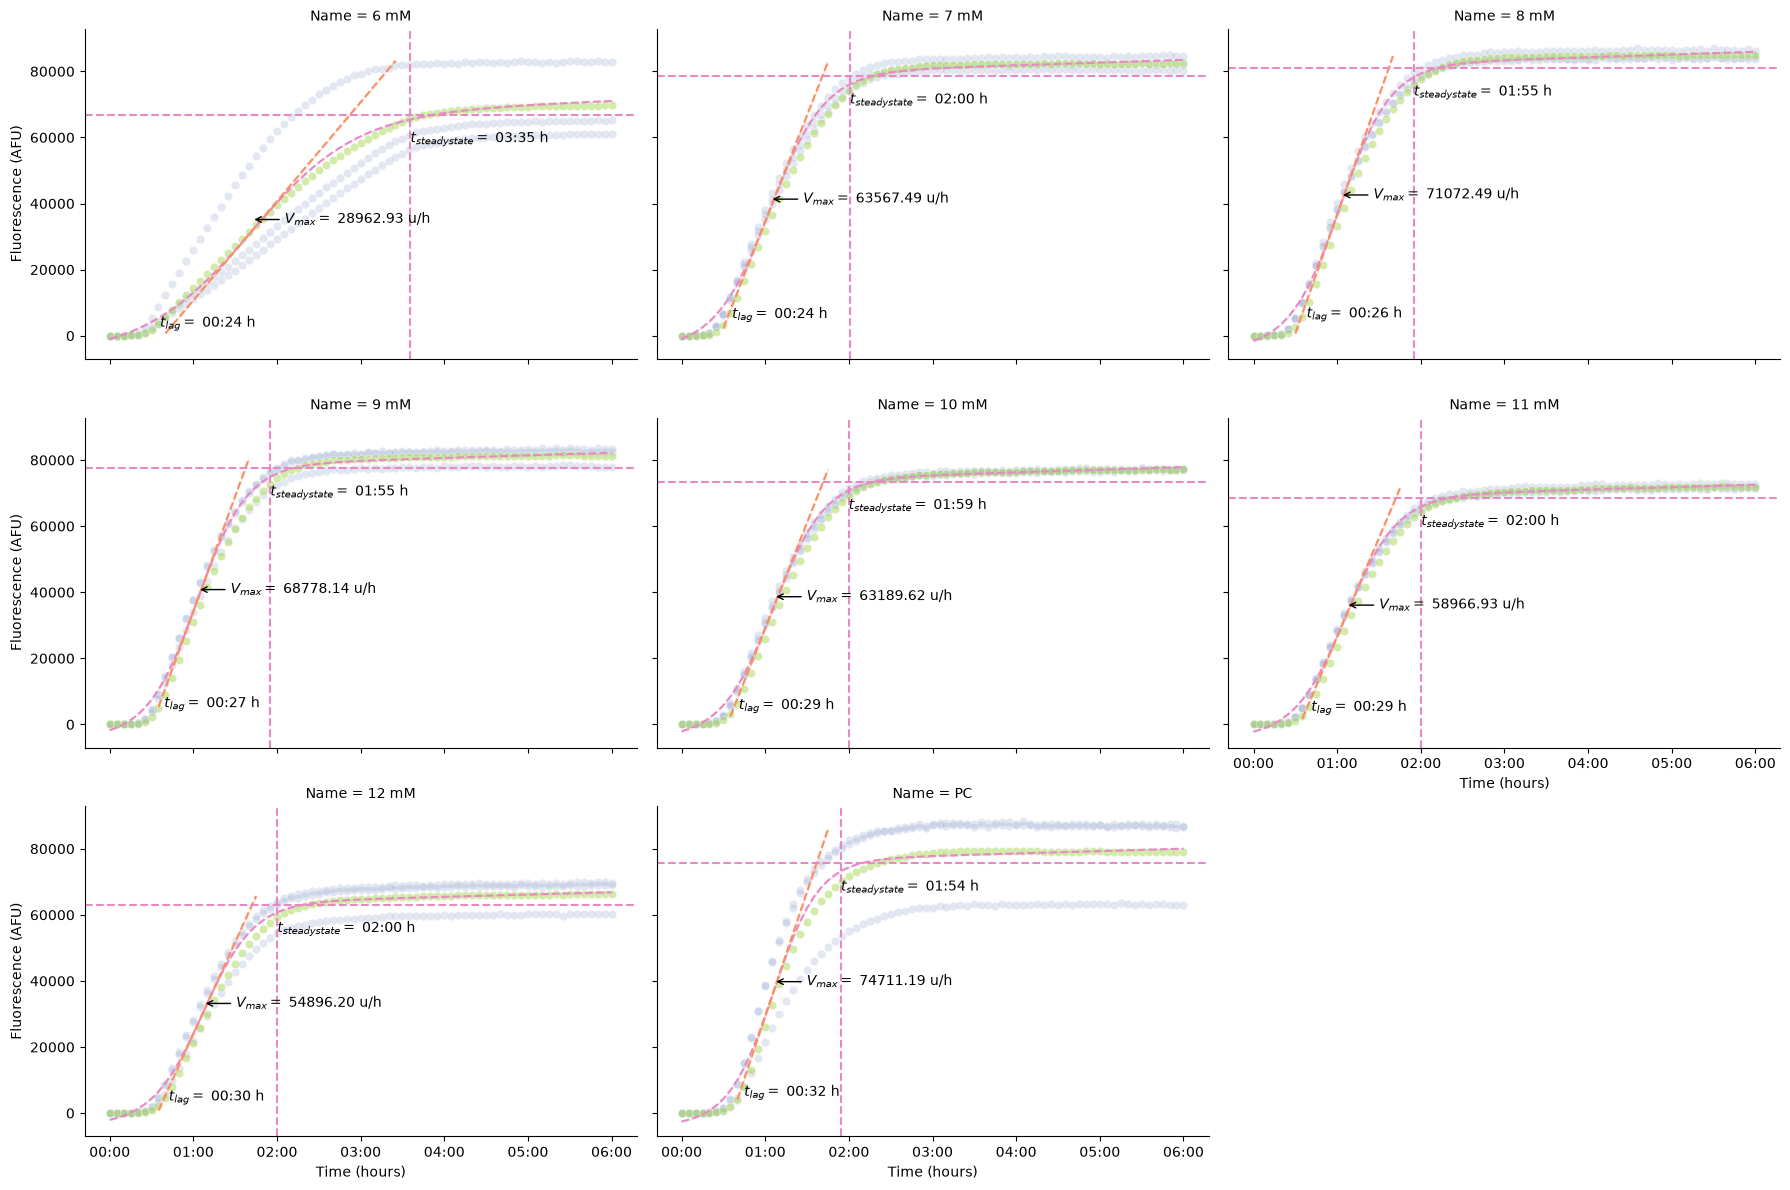

In [8]:
pr.plot_kinetics(data[data["Read"] == "GFP-F-G35"])

We can also calculate the kinetics and display the parameters as a table.

In [9]:
pr.kinetic_analysis(data)

Velocity                    \
                                           Time     Data      Max   
Name  Read       Well                                               
6 mM  GFP-F-G35  A11  0 days 01:56:29.513098057 31292.02 21092.30   
                 A14  0 days 01:50:13.811959456 32609.94 22934.22   
                 A17  0 days 01:18:12.455630114 41581.77 42862.28   
7 mM  GFP-F-G35  C11  0 days 01:04:19.334148628 40363.21 61484.21   
                 C13  0 days 01:02:24.211241934 42415.89 66033.37   
                 C17  0 days 01:03:10.219393371 41199.27 63184.88   
8 mM  GFP-F-G35  E11  0 days 01:02:33.625793983 42073.76 69609.93   
                 E14  0 days 01:02:27.419204752 42274.62 69875.31   
                 E17  0 days 01:01:26.876688758 43418.94 73732.22   
9 mM  GFP-F-G35  G11  0 days 01:02:22.486470248 41353.41 70649.58   
                 G14  0 days 01:02:07.418827316 41804.46 70851.55   
                 G17  0 days 01:03:55.903321569 39254.22 64833.30   
10 mM GFP-F-G35  I11  0 days 01:05:09.905241472 38757.28 64662.45   
                 I14  0 days 01:05:53.913354691 38688.20 62839.82   
                 I17  0 days 01:06:24.446067840 38492.59 62066.59   
11 mM GFP-F-G35  K11  0 days 01:06:15.659979307 35905.37 58903.82   
                 K14  0 days 01:06:14.094782107 36536.78 59707.68   
                 K17  0 days 01:06:14.368689100 35857.14 58289.28   
12 mM GFP-F-G35  M11  0 days 01:05:26.791847469 34878.79 58405.16   
                 M14  0 days 01:05:51.048054492 34516.94 57546.89   
                 M17  0 days 01:09:01.074653481 30179.18 48736.56   
PC    GFP-F-G35  O11  0 days 01:10:53.155347405 31684.37 49317.72   
                 O14  0 days 01:03:17.028348588 44079.09 88459.10   
                 O17  0 days 01:03:21.880329926 43578.98 86356.74   
6 mM  GFP-M-G100 A11  0 days 02:20:02.121653299 15027.93 10325.76   
                 A14  0 days 02:15:23.583137648 16217.73 11277.84   
                 A17  0 days 01:48:59.369136217 26661.69 22877.59   
7 mM  GFP-M-G100 C11  0 days 01:22:17.159524449 24820.85 32245.02   
                 C13  0 days 01:22:00.708523489 24988.54 30939.51   
                 C17  0 days 01:21:10.277839634 25512.21 32219.22   
8 mM  GFP-M-G100 E11  0 days 01:19:56.515965492 27206.50 35772.22   
                 E14  0 days 01:20:12.098504439 27458.52 35535.43   
                 E17  0 days 01:20:16.616977800 27073.79 34628.49   
9 mM  GFP-M-G100 G11  0 days 01:17:02.966466703 22090.99 30358.75   
                 G14  0 days 01:17:33.339356642 20189.80 27776.37   
                 G17  0 days 01:16:42.161812183 22081.78 30317.70   
10 mM GFP-M-G100 I11  0 days 01:17:15.535625755 19157.90 26714.03   
                 I14  0 days 01:17:42.932617648 17009.74 23338.39   
                 I17  0 days 01:18:22.878800172 17619.43 23877.03   
11 mM GFP-M-G100 K11  0 days 01:15:27.148401352 14974.69 21355.61   
                 K14  0 days 01:16:13.517827644 15254.46 22030.22   
                 K17  0 days 01:15:53.066835644 16508.58 22922.20   
12 mM GFP-M-G100 M11  0 days 01:13:59.584129456 14894.47 22270.64   
                 M14  0 days 01:14:22.433292866 14804.43 21466.76   
                 M17  0 days 01:15:50.024038139 13899.98 20006.01   
PC    GFP-M-G100 O11  0 days 01:19:11.502914437 19727.08 26170.25   
                 O14  0 days 01:21:13.406707551 28603.86 39550.76   
                 O17  0 days 01:20:44.353579848 27246.88 37445.82   

                                            Lag          \
                                           Time    Data   
Name  Read       Well                                     
6 mM  GFP-F-G35  A11  0 days 00:27:28.640797441 3256.18   
                 A14  0 days 00:24:55.007723318 3310.19   
                 A17  0 days 00:20:00.005976931 3967.72   
7 mM  GFP-F-G35  C11  0 days 00:24:56.003044759 6363.03   
                 C13  0 days 00:23:51.786591489 5946.84   
                 C17  0 days 00:24:02.863720033